# **1) Laod Dataset**

In [1]:
# Import required libraries for file handling and visualizationimport os
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

base_path = os.path.join('..', 'data', 'datasets')

train_path = os.path.join(base_path, 'Train')
test_a_path = os.path.join(base_path, 'Test-A')
test_b_path = os.path.join(base_path, 'Test-B')

print("Folders:", os.listdir(base_path))
print("Train:", os.listdir(train_path))

Folders: ['Test-A', 'Test-B', 'Train']
Train: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


In [2]:
import os
import tensorflow as tf

base_path = os.path.join('..', 'data', 'datasets')

train_path = os.path.join(base_path, 'Train')
test_a_path = os.path.join(base_path, 'Test-A')
test_b_path = os.path.join(base_path, 'Test-B')

print("base_path =", os.path.abspath(base_path))
print("train_path =", os.path.abspath(train_path))
print("test_a_path =", os.path.abspath(test_a_path))
print("test_b_path =", os.path.abspath(test_b_path))

print("Train classes:", os.listdir(train_path))
print("Test-A classes:", os.listdir(test_a_path))
print("Test-B classes:", os.listdir(test_b_path))

train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    test_a_path,
    image_size=(224, 224),
    batch_size=32
)

base_path = c:\Users\kadi9\OneDrive\Desktop\GP_project\data\datasets
train_path = c:\Users\kadi9\OneDrive\Desktop\GP_project\data\datasets\Train
test_a_path = c:\Users\kadi9\OneDrive\Desktop\GP_project\data\datasets\Test-A
test_b_path = c:\Users\kadi9\OneDrive\Desktop\GP_project\data\datasets\Test-B
Train classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Test-A classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Test-B classes: ['Lymphocyte', 'Neutrophil']
Found 10175 files belonging to 5 classes.
Found 4339 files belonging to 5 classes.


In [3]:
# Print folders inside the dataset directory
print("Folders inside dataset:")
print(os.listdir(base_path))

Folders inside dataset:
['Test-A', 'Test-B', 'Train']


In [4]:
# Display the classes inside each dataset folder
for folder in os.listdir(base_path):

    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):
        print(folder,"->",os.listdir(folder_path))

Test-A -> ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Test-B -> ['Lymphocyte', 'Neutrophil']
Train -> ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


## **2) Dataset Analysis**

In [5]:
# Get class names from the training dataset
classes = os.listdir(train_path)

print("Number of classes:",len(classes))

print("\nClass names:")
for c in classes:
    print(c)

Number of classes: 5

Class names:
Basophil
Eosinophil
Lymphocyte
Monocyte
Neutrophil


In [6]:
# Count number of images in each class
class_counts = {}

for class_name in classes:

    class_path = os.path.join(train_path,class_name)

    if os.path.isdir(class_path):

        images = os.listdir(class_path)
        class_counts[class_name] = len(images)

        print(class_name,":",len(images),"images")

Basophil : 212 images
Eosinophil : 744 images
Lymphocyte : 2427 images
Monocyte : 561 images
Neutrophil : 6231 images


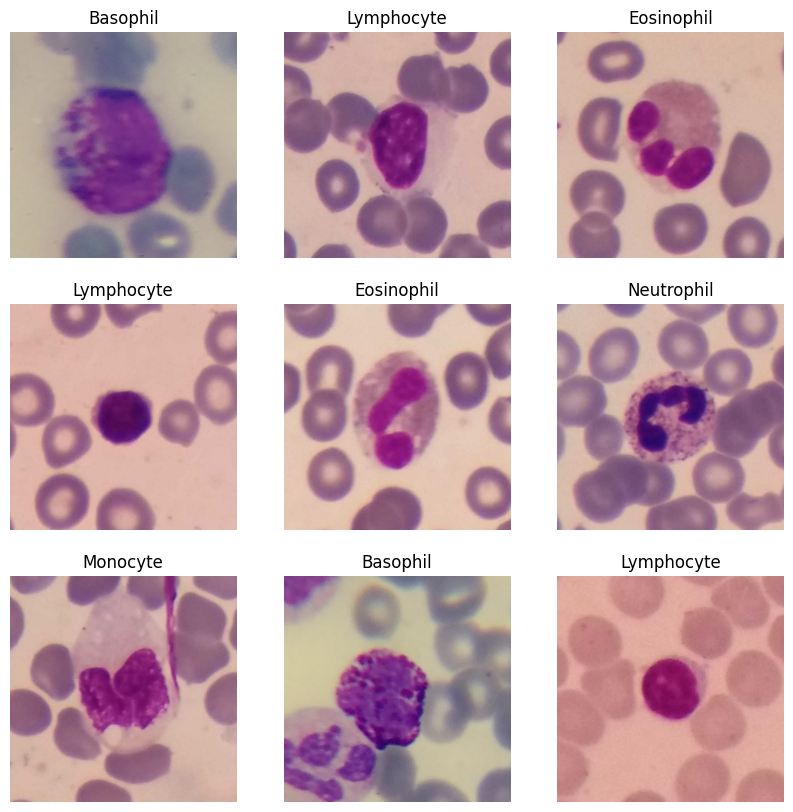

In [7]:
# Display sample images from the dataset

import random
from PIL import Image
plt.figure(figsize=(10,10))

for i in range(9):

    class_name = random.choice(classes)

    class_path = os.path.join(train_path, class_name)

    img_name = random.choice(os.listdir(class_path))

    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [8]:
# Check sample image sizes from the dataset
image_sizes = []

for class_name in classes:

    class_path = os.path.join(train_path,class_name)

    images = os.listdir(class_path)[:5]

    for img_name in images:

        img_path = os.path.join(class_path,img_name)

        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)
        except:
            pass

print("Sample image sizes:")
print(image_sizes[:10])

Sample image sizes:
[(575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575)]


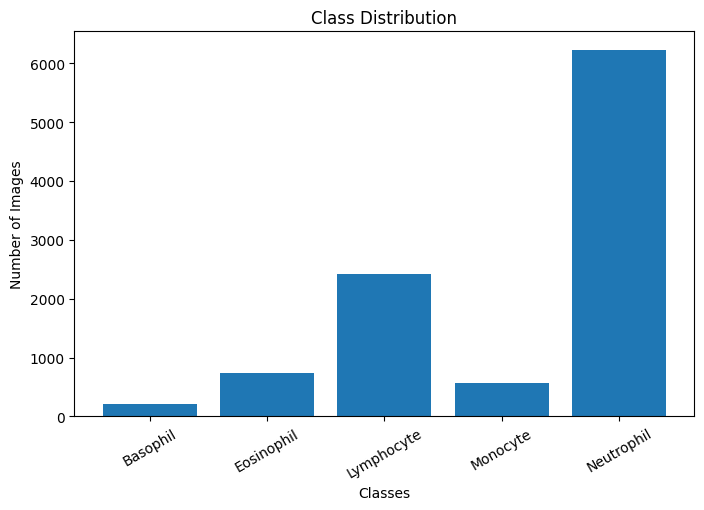

In [9]:
# Plot dataset class distribution
plt.figure(figsize=(8,5))

plt.bar(class_counts.keys(),class_counts.values())

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.show()

In [10]:
# Check if dataset is balanced or imbalanced
max_count = max(class_counts.values())
min_count = min(class_counts.values())

if max_count - min_count > 0:
    print("Dataset has class imbalance")
else:
    print("Dataset is balanced")

Dataset has class imbalance


# **3) Dataset Partitioning (70 / 15 / 15)**

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# Collect image paths and their corresponding labels

image_paths = []
labels = []

for class_name in os.listdir(train_path):

    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):

        for img in os.listdir(class_path):

            image_paths.append(os.path.join(class_path, img))
            labels.append(class_name)

print("Total images:", len(image_paths))

Total images: 10175


In [13]:
# First split: 70% Train and 30% temporary data

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(

    image_paths,
    labels,

    test_size = 0.30,

    stratify = labels,

    random_state = 42
)

In [14]:
# Second split: divide the remaining 30% into 15% Validation and 15% Test

val_imgs, test_imgs, val_labels, test_labels = train_test_split(

    temp_imgs,
    temp_labels,

    test_size = 0.50,

    stratify = temp_labels,

    random_state = 42
)

In [15]:
# Print dataset sizes after splitting

print("Training images:", len(train_imgs))
print("Validation images:", len(val_imgs))
print("Testing images:", len(test_imgs))

Training images: 7122
Validation images: 1526
Testing images: 1527


## **4) Image Preprocessing**

In [16]:
def rgb_to_hsi(img):
    img = img.astype(np.float32) / 255.0

    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    # Intensity
    I = (R + G + B) / 3.0

    # Saturation
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = np.zeros_like(I)
    denom = R + G + B
    mask = denom > 1e-8
    S[mask] = 1 - (3 * min_rgb[mask] / denom[mask])

    # Hue
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B)) + 1e-8
    theta = np.arccos(np.clip(num / den, -1, 1))

    H = np.zeros_like(I)
    H[B <= G] = theta[B <= G]
    H[B > G] = 2 * np.pi - theta[B > G]

    H = H / (2 * np.pi)  # normalize to [0,1]

    return np.stack([H, S, I], axis=-1)


def hsi_to_rgb(hsi):
    H = hsi[:, :, 0] * 2 * np.pi
    S = hsi[:, :, 1]
    I = hsi[:, :, 2]

    R = np.zeros_like(I)
    G = np.zeros_like(I)
    B = np.zeros_like(I)

    # Sector 1: 0 <= H < 2pi/3
    mask1 = (H >= 0) & (H < 2 * np.pi / 3)
    B[mask1] = I[mask1] * (1 - S[mask1])
    R[mask1] = I[mask1] * (
        1 + (S[mask1] * np.cos(H[mask1])) / (np.cos(np.pi / 3 - H[mask1]) + 1e-8)
    )
    G[mask1] = 3 * I[mask1] - (R[mask1] + B[mask1])

    # Sector 2: 2pi/3 <= H < 4pi/3
    mask2 = (H >= 2 * np.pi / 3) & (H < 4 * np.pi / 3)
    H2 = H[mask2] - 2 * np.pi / 3
    R[mask2] = I[mask2] * (1 - S[mask2])
    G[mask2] = I[mask2] * (
        1 + (S[mask2] * np.cos(H2)) / (np.cos(np.pi / 3 - H2) + 1e-8)
    )
    B[mask2] = 3 * I[mask2] - (R[mask2] + G[mask2])

    # Sector 3: 4pi/3 <= H < 2pi
    mask3 = (H >= 4 * np.pi / 3) & (H < 2 * np.pi)
    H3 = H[mask3] - 4 * np.pi / 3
    G[mask3] = I[mask3] * (1 - S[mask3])
    B[mask3] = I[mask3] * (
        1 + (S[mask3] * np.cos(H3)) / (np.cos(np.pi / 3 - H3) + 1e-8)
    )
    R[mask3] = 3 * I[mask3] - (G[mask3] + B[mask3])

    rgb = np.stack([R, G, B], axis=-1)
    rgb = np.clip(rgb, 0, 1)
    rgb = (rgb * 255).astype(np.uint8)

    return rgb


def preprocess_image_hsi(img_path, size=(224, 224)):
    # read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # resize
    img = cv2.resize(img, size)

    # RGB -> HSI
    hsi = rgb_to_hsi(img)

    # split HSI channels
    H = hsi[:, :, 0]
    S = hsi[:, :, 1]
    I = hsi[:, :, 2]

    # Histogram Equalization on Intensity
    I_uint8 = np.clip(I * 255, 0, 255).astype(np.uint8)
    I_eq = cv2.equalizeHist(I_uint8).astype(np.float32) / 255.0

    # replace original intensity channel
    hsi_eq = np.stack([H, S, I_eq], axis=-1)

    # HSI -> RGB
    img_eq = hsi_to_rgb(hsi_eq)

    # normalization
    img_eq = img_eq.astype("float32") / 255.0

    return img_eq

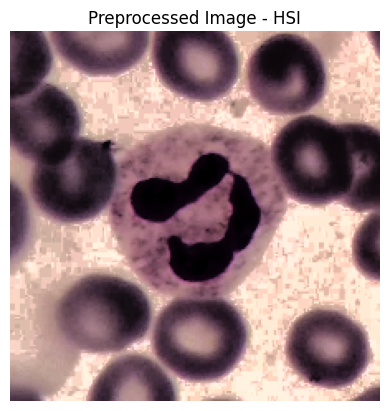

In [17]:
import cv2
sample = preprocess_image_hsi(train_imgs[0])

plt.imshow(sample)
plt.title("Preprocessed Image - HSI")
plt.axis("off")
plt.show()



In [18]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(128, 128),
    batch_size=8
)

val_data = tf.keras.utils.image_dataset_from_directory(
    test_a_path,
    image_size=(128, 128),
    batch_size=8
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_b_path,
    image_size=(128, 128),
    batch_size=8
)

# احفظي أسماء الكلاسات هنا
class_names = train_data.class_names
print("Class names:", class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)
test_data = test_data.prefetch(buffer_size=AUTOTUNE)

Found 10175 files belonging to 5 classes.
Found 4339 files belonging to 5 classes.
Found 2119 files belonging to 2 classes.
Class names: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


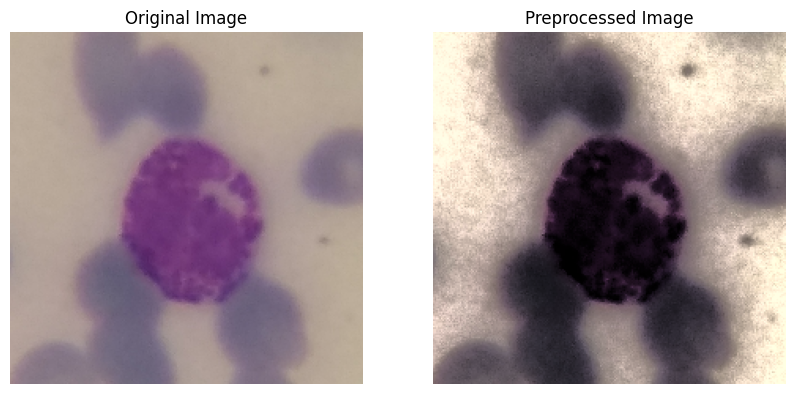

In [19]:
# Test preprocessing on one sample image

sample_class = classes[0]
sample_image_name = os.listdir(os.path.join(train_path, sample_class))[0]
sample_image_path = os.path.join(train_path, sample_class, sample_image_name)

# Original image
original = cv2.imread(sample_image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
original = cv2.resize(original, (224, 224))

# Processed image
processed = preprocess_image_hsi(sample_image_path)

# Display comparison
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed)
plt.title("Preprocessed Image")
plt.axis("off")

plt.show()

# 5) Augmentation

In [20]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomContrast(0.3),
])

In [21]:
import os

# Get class names from the Train folder
class_names = sorted(os.listdir(train_path))

# Create mapping: class name -> index
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

# Print result
print("Class names:", class_names)
print("Class to index mapping:", class_to_idx)

Class names: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Class to index mapping: {'Basophil': 0, 'Eosinophil': 1, 'Lymphocyte': 2, 'Monocyte': 3, 'Neutrophil': 4}


In [22]:
# TensorFlow data augmentation only (no PyTorch Dataset needed)

train_data = train_data.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

val_data = val_data.map(
    lambda x, y: (x, y)
)

test_data = test_data.map(
    lambda x, y: (x, y)
)

print("Train batches:", tf.data.experimental.cardinality(train_data).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_data).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_data).numpy())

Train batches: 1272
Validation batches: 543
Test batches: 265


In [23]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_data = val_data.map(
    lambda x, y: (x, y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_data = test_data.map(
    lambda x, y: (x, y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

print("Augmentation applied successfully")

Augmentation applied successfully


In [24]:
# Check one batch from TensorFlow dataset
for images, labels in train_data.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("First labels:", labels[:5].numpy())

Images shape: (8, 128, 128, 3)
Labels shape: (8,)
First labels: [4 4 4 4 4]


# 6) Model Selection & Transfer Learning

In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [28]:
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Number of classes: 5


In [29]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [30]:
model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [33]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 431s 335ms/step - accuracy: 0.6094 - loss: 1.0722 - val_accuracy: 0.6130 - val_loss: 1.0509 - learning_rate: 0.0010
Epoch 2/10
  58/1272 ━━━━━━━━━━━━━━━━━━━━ 3:00 149ms/step - accuracy: 0.6321 - loss: 0.9717

KeyboardInterrupt: 

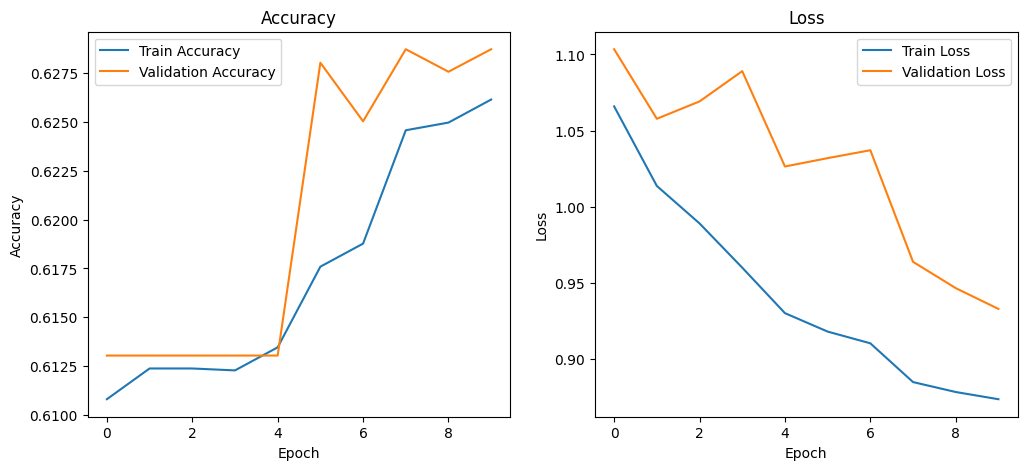

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

265/265 ━━━━━━━━━━━━━━━━━━━━ 33s 124ms/step - accuracy: 0.0514 - loss: 2.1577
Test Loss: 2.157700777053833
Test Accuracy: 0.05143935978412628


In [ ]:
for images, labels in test_data.take(1):
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    print("True labels:     ", labels.numpy()[:10])
    print("Predicted labels:", predicted_classes[:10])
    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
True labels:      [1 1 1 1 1 1 1 0]
Predicted labels: [4 4 0 4 4 0 4 0]


In [ ]:
model_name = "efficientnetv2_rw_s"
model = timm.create_model(model_name, pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final classifier
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, num_classes)

# Train only classifier
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

print("Model loaded successfully")
print(model.classifier)

NameError: name 'timm' is not defined

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

: 

: 

: 

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1

: 

: 

: 

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds

: 

: 

: 

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")


Epoch 1/10
Train Loss: 0.8048 | Train Acc: 0.7282 | Train F1: 0.6752
Val   Loss: 0.6729 | Val   Acc: 0.7883 | Val   F1: 0.7584

Epoch 2/10
Train Loss: 0.6163 | Train Acc: 0.7895 | Train F1: 0.7603
Val   Loss: 0.5913 | Val   Acc: 0.8047 | Val   F1: 0.7831

Epoch 3/10
Train Loss: 0.5472 | Train Acc: 0.8096 | Train F1: 0.7877
Val   Loss: 0.5660 | Val   Acc: 0.7995 | Val   F1: 0.7905

Epoch 4/10
Train Loss: 0.5165 | Train Acc: 0.8189 | Train F1: 0.8016
Val   Loss: 0.5290 | Val   Acc: 0.8132 | Val   F1: 0.8052

Epoch 5/10
Train Loss: 0.4967 | Train Acc: 0.8253 | Train F1: 0.8096
Val   Loss: 0.4886 | Val   Acc: 0.8224 | Val   F1: 0.8106

Epoch 6/10
Train Loss: 0.4875 | Train Acc: 0.8224 | Train F1: 0.8083
Val   Loss: 0.4912 | Val   Acc: 0.8290 | Val   F1: 0.8205

Epoch 7/10
Train Loss: 0.4704 | Train Acc: 0.8309 | Train F1: 0.8188
Val   Loss: 0.5108 | Val   Acc: 0.8100 | Val   F1: 0.7987

Epoch 8/10
Train Loss: 0.4600 | Train Acc: 0.8409 | Train F1: 0.8287
Val   Loss: 0.4776 | Val   Acc: 0.

: 

: 

: 

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in list(model.parameters())[-20:]:
    param.requires_grad = True

print("Last 20 parameter tensors are now trainable.")

Last 20 parameter tensors are now trainable.


: 

: 

: 

In [ ]:
trainable_params = 0
frozen_params = 0

for param in model.parameters():
    if param.requires_grad:
        trainable_params += param.numel()
    else:
        frozen_params += param.numel()

print("Trainable parameters:", trainable_params)
print("Frozen parameters:", frozen_params)

Trainable parameters: 1633737
Frozen parameters: 20523524


: 

: 

: 

In [ ]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

: 

: 

: 

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    print(f"\nFine-tuning Epoch {epoch+1}/{num_epochs}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")


Fine-tuning Epoch 1/5
Train Loss: 0.3638 | Train Acc: 0.8715 | Train F1: 0.8635
Val   Loss: 0.3179 | Val   Acc: 0.8945 | Val   F1: 0.8923

Fine-tuning Epoch 2/5
Train Loss: 0.2598 | Train Acc: 0.9104 | Train F1: 0.9060
Val   Loss: 0.2297 | Val   Acc: 0.9128 | Val   F1: 0.9087

Fine-tuning Epoch 3/5


: 

: 

: 

In [ ]:
torch.save(model.state_dict(), "efficientnet_finetuned.pth")
print("Model saved successfully")

: 

: 

: 

In [ ]:
import torch

: 

: 

: 

# 7) Feature Extraction

In [ ]:
# Remove classifier (we only want features)
model.classifier = torch.nn.Identity()

model.eval()

: 

: 

: 

In [ ]:
def extract_features(model, loader, device):
    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            features = model(images)
            features = features.cpu().numpy()
            labels = labels.cpu().numpy()

            all_features.append(features)
            all_labels.append(labels)

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_features, all_labels

: 

: 

: 

In [ ]:
X_train_feat, y_train_feat = extract_features(model, train_loader, device)
X_val_feat, y_val_feat = extract_features(model, val_loader, device)
X_test_feat, y_test_feat = extract_features(model, test_loader, device)

print("Train:", X_train_feat.shape)
print("Val:", X_val_feat.shape)
print("Test:", X_test_feat.shape)

: 

: 

: 